# 神经网络超参数搜索

这份 notebook 的主题不是“换一个模型”，而是理解为什么同一个模型在不同超参数下，训练效果会差很多。

## 什么是超参数
- 不是训练学出来的，而是我们事先设定的。
- 常见的有学习率、batch size、网络宽度、优化器类型等。

超参数搜索的本质，是在验证集上比较不同配置的泛化能力，而不是只看训练集 loss 有没有下降。


In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize
from matplotlib import pyplot as plt
from tqdm import tqdm
from torch import nn

import torch
import numpy as np
import pandas as pd
import os

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. 回归任务里的目标是什么

这里依旧使用房价预测。和分类不同，回归任务预测的是连续值，所以我们更关心预测误差有多大，而不是是否分对类别。


In [2]:
housing = fetch_california_housing(data_home='../data')

x_train_, x_test, y_train_, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_, y_train_, test_size=0.25, random_state=42
)

dataset_maps = {
    'train': (x_train, y_train),
    'val': (x_val, y_val),
    'test': (x_test, y_test)
}

std = StandardScaler()
std.fit(x_train)


class HousingDataset(Dataset):
    def __init__(self, dataset_type='train'):
        self.x, self.y = dataset_maps[dataset_type]
        self.x = std.transform(self.x)
        self.x = torch.tensor(self.x, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

## 2. 为什么要固定数据管道再调参

调参之前，数据划分、标准化、DataLoader 都要先稳定下来。否则你根本无法判断性能变化到底来自模型超参数，还是来自数据处理方式变化。


In [3]:
batch_size = 256

train_ds = HousingDataset('train')
val_ds = HousingDataset('val')
test_ds = HousingDataset('test')

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

## 3. 网络结构只是调参对象之一

模型结构决定表达能力，但训练效果还受学习率、动量、训练轮数等因素影响。

可以把它理解成：
- 结构决定“模型能学多复杂”。
- 超参数决定“模型能不能学得动、学得稳”。


In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=8):
        super(NeuralNetwork, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

## 4. 为什么验证集比训练集更重要

调参最怕的就是把训练集拟合得很好，却在新数据上失效。验证集的作用，就是替我们提前发现这种问题。

所以网格搜索真正要优化的目标，不是训练损失最小，而是验证集表现最好。


In [5]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.wait = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
        return self.wait >= self.patience

In [6]:
# 保存模型检查点
class CheckPointing:
    def __init__(self, save_path, model_name, save_step=100, save_best_only=True):
        self.save_step = save_step
        self.save_path = save_path
        self.model_name = model_name
        self.save_best_only = save_best_only
        self.best_metric = -1

        if not os.path.exists(save_path):
            os.makedirs(save_path)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return
        if self.save_best_only:
            assert metric is not None, "metric must be provided when save_best_only is True"
            if metric >= self.best_metric:
                self.best_metric = metric
                torch.save(state_dict, os.path.join(
                    self.save_path, f'best_{self.model_name}.ckpt'))
        else:
            torch.save(state_dict, os.path.join(
                self.save_path, f'{self.model_name}_step_{step}.ckpt'))

In [7]:
@torch.no_grad()
def evaluate(model, dataloder, loss_fn):
    loss_list = []
    for datas, labels in dataloder:
        datas, labels = datas.to(device), labels.to(device)
        logits = model(datas)
        loss = loss_fn(logits, labels)
        loss_list.append(loss.item())
    return np.mean(loss_list)

## 5. 学习率搜索在看什么

学习率是最敏感的超参数之一：
- 太大：loss 震荡，甚至不收敛。
- 太小：下降很慢，训练时间长。
- 合适：下降平稳，验证集表现也更好。

后面的曲线对比，核心就是观察不同学习率下的收敛速度和稳定性。


In [8]:
def train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=100,
    eval_interval=200,
    earlystopper=None,
    checkpointer=None
):
    records = {
        'train_loss': [],
        'val_loss': []
    }

    global_step = 0

    with tqdm(total=epochs * len(train_loader), desc='Training') as pbar:
        for epoch in range(epochs):
            model.train()
            for datas, labels in train_loader:
                datas, labels = datas.to(device), labels.to(device)
                optimizer.zero_grad()
                logits = model(datas)
                loss = loss_fn(logits, labels)
                loss.backward()
                optimizer.step()

                records['train_loss'].append(loss.item())

                if global_step % eval_interval == 0:
                    model.eval()
                    val_loss = evaluate(model, val_loader, loss_fn)
                    records['val_loss'].append(val_loss)

                    pbar.set_postfix({
                        'train_loss': f'{loss.item():.4f}',
                        'val_loss': f'{val_loss:.4f}'
                    })

                    if checkpointer is not None:
                        checkpointer(
                            global_step, model.state_dict(), metric=-val_loss)

                    if earlystopper is not None and earlystopper(val_loss):
                        print(
                            f'Early stopping at epoch {epoch}, step {global_step}')
                        return records

                global_step += 1
                pbar.set_postfix({'epoch': epoch})
                pbar.update(1)

    return records

Training:  94%|█████████▍| 4600/4900 [00:11<00:00, 405.45it/s, train_loss=0.3443, val_loss=0.3112]


Early stopping at epoch 93, step 4600
Learning Rate: 0.01, Final Train Loss: 0.3443, Final Val Loss: 0.3112


Training:  69%|██████▉   | 3400/4900 [00:07<00:03, 428.53it/s, train_loss=0.2790, val_loss=0.3140]


Early stopping at epoch 69, step 3400
Learning Rate: 0.03, Final Train Loss: 0.2790, Final Val Loss: 0.3140


Training:  41%|████      | 2000/4900 [00:04<00:06, 446.91it/s, train_loss=nan, val_loss=nan]


Early stopping at epoch 40, step 2000
Learning Rate: 0.3, Final Train Loss: nan, Final Val Loss: nan


Training: 100%|██████████| 4900/4900 [00:11<00:00, 421.70it/s, epoch=99]                          


Learning Rate: 0.001, Final Train Loss: 0.2109, Final Val Loss: 0.3685


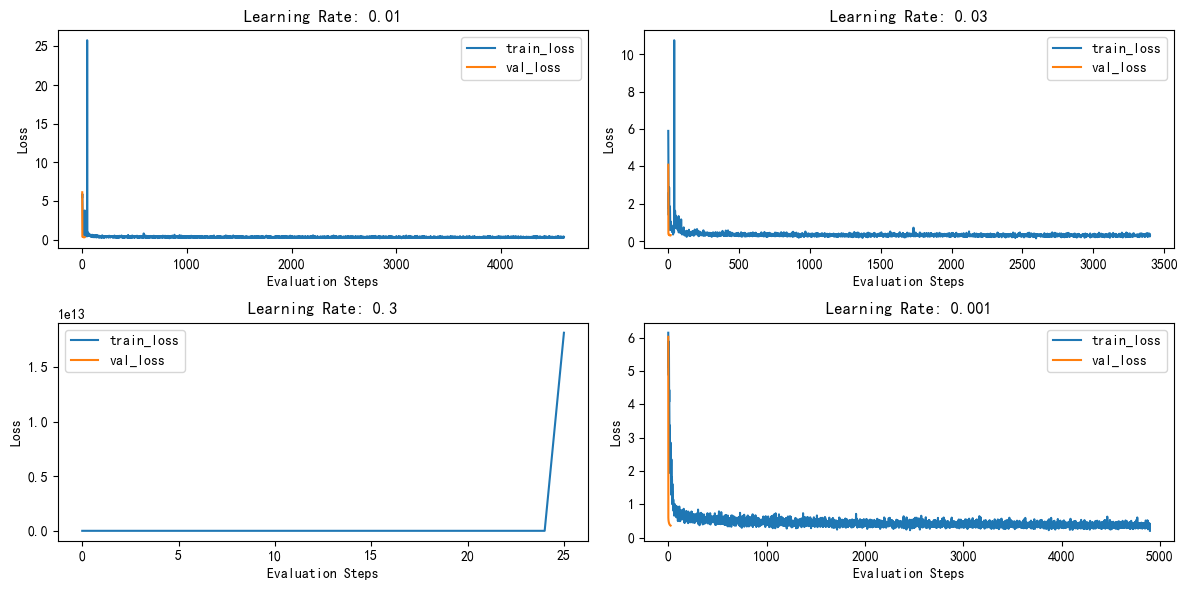

In [ ]:
# 实现网格搜索

plt.figure(figsize=(12, 6))

for i, lr in enumerate([1e-2, 3e-2, 3e-1, 1e-3]):

    model = NeuralNetwork().to(device)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    earlystopper = EarlyStopping(patience=10, min_delta=0.01)
    # checkpointer = CheckPointing(
    #     save_path="./checkpoints", model_name="lr_{}".format(lr), save_step=100, save_best_only=True)

    records = train(
        model, train_loader, val_loader, loss_fn, optimizer,
        epochs=100, eval_interval=200,
        earlystopper=earlystopper,
        # checkpointer=checkpointer
    )

    # 输出结果
    print(
        f'Learning Rate: {lr}, Final Train Loss: {records["train_loss"][-1]:.4f}, Final Val Loss: {records["val_loss"][-1]:.4f}')

    plt.subplot(2, 2, i + 1)
    plt.plot(records['train_loss'], label='train_loss')
    plt.plot(records['val_loss'], label='val_loss')
    plt.title(f'Learning Rate: {lr}')
    plt.xlabel('Evaluation Steps')
    plt.ylabel('Loss')
    plt.legend()

plt.tight_layout()
plt.show()